In [158]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import sqlite3
# uses the DB created in https://github.com/reebme/curated-data-sqlite
from config import DB_PATH

# uses functions from https://github.com/reebme/curated-data-sqlite
# from src/utils.py
CURATED_DATA = Path("../../Curated_Data_SQLite").resolve()
sys.path.append(str(CURATED_DATA / "src"))
import utils

import pandas as pd
import numpy as np

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [49]:
sql_folder = "../Sql/"

# The experiment, multivariate normal n = 4 (visualization of the transformations)

In [149]:
rng = np.random.default_rng()

In [150]:
# no of dimensions
d = 3000
# no of data points
n = 4

# n x d feature matrix
X = rng.standard_normal((n, d))

## Centering the vectors
Pearson's correlation is invariant under affine transformations (up to a sign) and fully invariant under Z-score transformations. Therefore, without loss of generality, we consider vectors sampled from the standard multivariate normal distribution:
$$
X_j \sim \mathcal N_n(0,I_n), \qquad j=1,\ldots,d.
$$

The centering below is not a preprocessing step. It is the centering that appears in the definition of Pearson's correlation.

For the j-th vector, the sample mean is:
$$ \overline{X_j} = \frac{1}{n}\sum_{i=1}^n X_{ij} $$

and sample means form a row vector:
$$
\overline{X} = \left[\overline{X_1}, \dots, \overline{X_d}\right]
$$

Then centering gives:
$$ 
\widetilde{X} = X - \mathbb{1}_n\overline{X}
$$

where n x 1

$$
\mathbf{1}_n =
\begin{bmatrix}
1 \\
\vdots \\
1 \\
\end{bmatrix}
$$

We know that sum of coordinates of a centered vector is 0:
$$
\forall j = 1\dots d: \ \sum_{i=1}^{n}\widetilde{X_{ij}}=0
$$

so every centered vector lies in the hyperplane

$$
H=\left\{z\in\mathbb{R}^n:\sum_{i=1}^{n}z_i=0\right\}
$$


In [151]:
# centering vectors required by the Pearson's correlation
tilde_X = X - X.mean(axis = 0, keepdims = True)

We know centered vectors are in the (n-1)-dim subspace, on a hyperplane orthogonal to the vector of ones.

PCA finds the sequence of orthogonal directions that capture as much variance as possible. Thus PCA finds an orthonormal basis

$$
v_1\dots v_n
$$

ordered by decreasing explained variance:

$$
\lambda_1\geq \dots \geq \lambda_n
$$

The eigendecomposition appears because the variance-maximization problem has eigenvectors as its solutions.

Since centering imposes a linear constraint:

$$
\forall j = 1\dots d: \ \mathbb{1}_n^T \ \widetilde{X_{\cdot j}} = 0
$$

all centered vectors lie in an (n−1)-dimensional subspace. Consequently, the covariance matrix has rank at most n−1, and one eigenvalue is exactly zero. Corresponding eigenvector is:

$$
v_n \propto \mathbb{1}_n
$$

(they have the same direction).

The orthonormal basis found by PCA provides a convenient coordinate system for representing and visualizing the vectors in the (n−1)-dimensional subspace. Since PCA only rotates the coordinate system, representing the data using all n−1 nonzero principal components preserves all variance.

In [152]:
pca = PCA()

hyperplane_points = pca.fit_transform(tilde_X.T)

print(pca.explained_variance_)
print(np.sum(pca.explained_variance_))
print(pca.explained_variance_ratio_)

[1.03327992e+00 1.00938462e+00 9.67620383e-01 7.19481644e-16]
3.0102849244603798
[3.43249873e-01 3.35311988e-01 3.21438139e-01 2.39007822e-16]


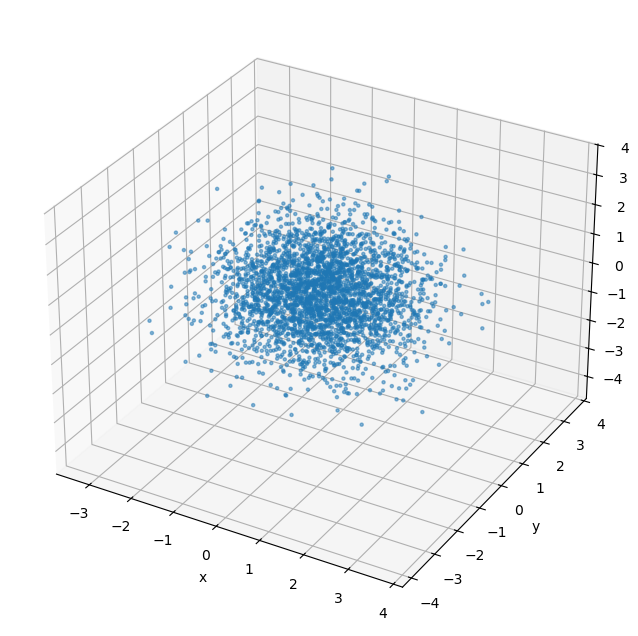

In [153]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(
    hyperplane_points[:, 0],
    hyperplane_points[:, 1],
    hyperplane_points[:, 2],
    s = 5,
    alpha = 0.5
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

## Normalizing the vectors

In [154]:
U = tilde_X / np.linalg.norm(tilde_X, axis = 0, keepdims=True)

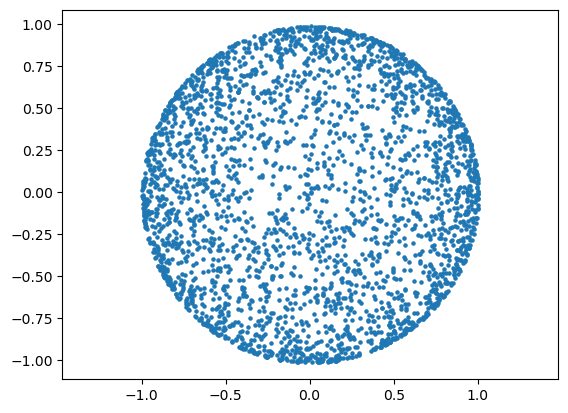

In [155]:
norm_coords = pca.fit_transform(U.T)
plt.scatter(norm_coords[:,0], norm_coords[:,1], s = 5)
plt.axis('equal')
plt.show()

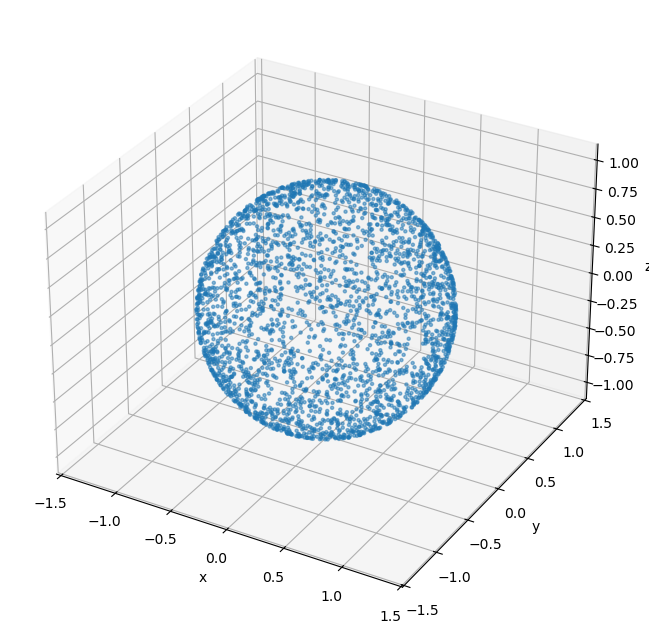

In [156]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(
    norm_coords[:, 1],
    norm_coords[:, 0],
    norm_coords[:, 2],
    s=5,
    alpha=0.5
)

ax.axis('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

In [132]:
pca.explained_variance_

array([0.34695493, 0.33289846, 0.32001463, 0.        ])

## Correlations

In [147]:
R = np.corrcoef(X, rowvar = False)
assert (np.round(R, 6) == np.round(U.T @ U, 6)).sum() == d**2

corrs = R[np.eye(d) != 1].ravel()

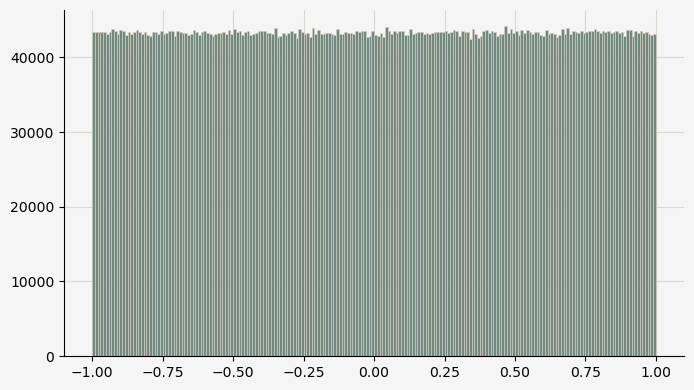

In [148]:
utils.pretty_histogram(corrs)

# The experiment, multivariate normal (correlation distribution visualization)

0.5


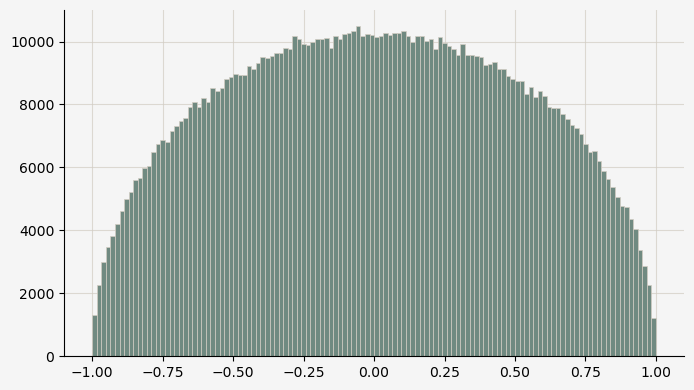

In [157]:
# no of dimensions
d = 1000
# no of data points
n = 5
print(1/np.sqrt(n - 1))

X = rng.standard_normal((n, d))

tilde_X = X - X.mean(axis = 0, keepdims = True)

U = tilde_X/np.linalg.norm(tilde_X, axis = 0, keepdims = True)
R = U.T @ U

utils.pretty_histogram(R[np.eye(d) != 1].ravel())